In [27]:
# 1. IMPORTATION DES LIBRAIRIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Outils de Scikit-Learn pour le Preprocessing (préparation des données)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder

# Le modèle algorithmique et les métriques
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error

In [28]:
# 2. CHARGEMENT DES DONNÉES ET PRÉPARATION

# Chargement des datasets d'entraînement et de test
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

# Séparation des features (X) et de la variable cible (y)
# On enlève 'Id' car elle n'a aucune utilité, et 'SalePrice' car c'est la variable qu'on veut prédire.
X_train = train_df.drop(['Id', 'SalePrice'], axis=1)

# Transformation Logarithmique de la Target
y_train = np.log1p(train_df['SalePrice'])

# Préparation du dataset de test (on garde juste l'Id de côté pour la soumission finale)
X_test = test_df.drop(['Id'], axis=1)
test_ids = test_df['Id']

In [29]:
# 3. IDENTIFICATION DES VARIABLES ET PREPROCESSING

# On identifie automatiquement quelles colonnes sont numériques et lesquelles sont des catégories
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object']).columns

# Création du "tuyau" (pipeline) de traitement pour les variables NUMÉRIQUES
numeric_transformer = Pipeline(steps=[
    # 1. S'il manque des valeurs, on les remplace par la médiane de la colonne
    ('imputer', SimpleImputer(strategy='median')),
    # 2. On met à l'échelle avec RobustScaler (insensible aux valeurs extrêmes/outliers)
    ('scaler', RobustScaler())
])

# Création du "tuyau" (pipeline) de traitement pour les variables CATÉGORIELLES
categorical_transformer = Pipeline(steps=[
    # 1. S'il manque du texte, on le remplace par la catégorie la plus fréquente
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # 2. On transforme le texte en colonnes de 0 et de 1 (One-Hot Encoding)
    # handle_unknown='ignore' évite les crashs si une catégorie existe dans test.csv mais pas dans train.csv
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# On combine les deux traitements dans un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [30]:
# 4. CRÉATION ET ENTRAÎNEMENT DU MODÈLE GLOBAL (PIPELINE)

# LassoCV va tester tout seul plein de valeurs pour 'alpha' via Cross-Validation (cv=5)
pipeline_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LassoCV(cv=5, random_state=42, max_iter=10000)) # max_iter élevé pour s'assurer que l'algorithme converge
])

# ENTRAÎNEMENT DU MODÈLE
print("Entraînement du modèle en cours... LassoCV cherche le meilleur alpha.")
pipeline_lasso.fit(X_train, y_train)

# On récupère le meilleur paramètre alpha trouvé par le modèle
best_alpha = pipeline_lasso.named_steps['model'].alpha_
print(f"Entraînement terminé ! Le meilleur hyperparamètre alpha trouvé est : {best_alpha:.5f}")

# Évaluation rapide sur le set d'entraînement (juste pour voir si on a bien appris)
y_pred_train = pipeline_lasso.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
print(f"RMSE sur le set d'entraînement (en log) : {rmse_train:.4f}")

Entraînement du modèle en cours... LassoCV cherche le meilleur alpha.
Entraînement terminé ! Le meilleur hyperparamètre alpha trouvé est : 0.00396
RMSE sur le set d'entraînement (en log) : 0.1393


In [31]:
# 5. INTERPRÉTATION : ANALYSE DES COEFFICIENTS (Sélection de variables)

# Récupération du modèle Lasso entraîné
lasso_model = pipeline_lasso.named_steps['model']

# Compter combien de variables ont été gardées (coefficient différent de 0) et éliminées (coefficient = 0)
coeffs = lasso_model.coef_
features_gardees = np.sum(coeffs != 0)
features_eliminees = np.sum(coeffs == 0)

print(f"Magie du Lasso : sur {len(coeffs)} variables créées après encodage,")
print(f"-> {features_gardees} ont été conservées.")
print(f"-> {features_eliminees} ont été réduites à 0 (jugées inutiles) !")

Magie du Lasso : sur 287 variables créées après encodage,
-> 41 ont été conservées.
-> 246 ont été réduites à 0 (jugées inutiles) !


In [32]:
# 6. PRÉDICTIONS SUR LE TEST SET ET SOUMISSION KAGGLE


# Prédire les prix pour le dataset de test
# prédictions en logarithme
preds_log = pipeline_lasso.predict(X_test)

# On applique l'exponentielle (np.expm1) pour annuler le logarithme et retrouver les prix en vrais dollars ($)
preds_dollars = np.expm1(preds_log)

# Création du DataFrame final au format attendu par Kaggle
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds_dollars
})

# Sauvegarde au format CSV (sans l'index par défaut de pandas)
fichier_soumission = 'M1_Lasso_Submission.csv'
submission.to_csv(fichier_soumission, index=False)

print(f"Fichier '{fichier_soumission}' généré avec succès ! ")
submission.head()

Fichier 'M1_Lasso_Submission.csv' généré avec succès ! 


,Id,SalePrice
0,1461,117597.540776
1,1462,137102.768576
2,1463,168758.079067
3,1464,200037.442969
4,1465,197096.005367


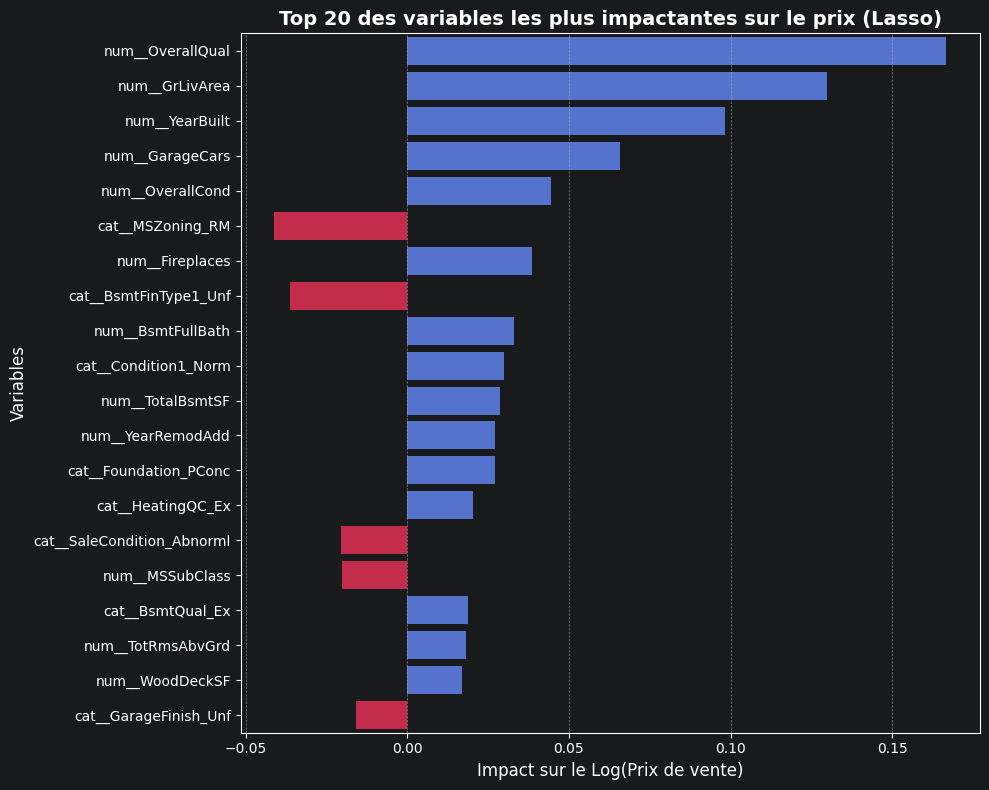

In [33]:
# 7. VISUALISATION : TOP 20 DES VARIABLES LES PLUS IMPORTANTES

# 1. Récupérer le nom de toutes les colonnes APRÈS le preprocessing
feature_names = pipeline_lasso.named_steps['preprocessor'].get_feature_names_out()

# 2. Créer un DataFrame associant le nom de la variable à son coefficient
coefs_df = pd.DataFrame({
    'Variable': feature_names,
    'Coefficient': lasso_model.coef_
})

# 3. On filtre pour enlever les variables que le Lasso a mises à 0
coefs_df = coefs_df[coefs_df['Coefficient'] != 0]

# 4. On crée une colonne avec la valeur absolue pour trouver les plus impactantes
coefs_df['Abs_Coefficient'] = coefs_df['Coefficient'].abs()

# 5. On prend le Top 20
top_20_features = coefs_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)

# 6. Création de la liste des couleurs (bleu si positif, rouge si négatif)
couleurs = top_20_features['Coefficient'].apply(lambda x: 'crimson' if x < 0 else 'royalblue').tolist()

# 7. Création du graphique
plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_20_features,
    x='Coefficient',
    y='Variable',
    hue='Variable',
    palette=couleurs,
    legend=False
)

plt.title("Top 20 des variables les plus impactantes sur le prix (Lasso)", fontsize=14, fontweight='bold')
plt.xlabel("Impact sur le Log(Prix de vente)", fontsize=12)
plt.ylabel("Variables", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Commentaire pour le Notebook :
# Les barres bleues (positives) augmentent le prix de la maison (ex: grande surface, quartier très coté).
# Les barres rouges (négatives) diminuent le prix de la maison (ex: mauvaise qualité, proximité d'une route bruyante).

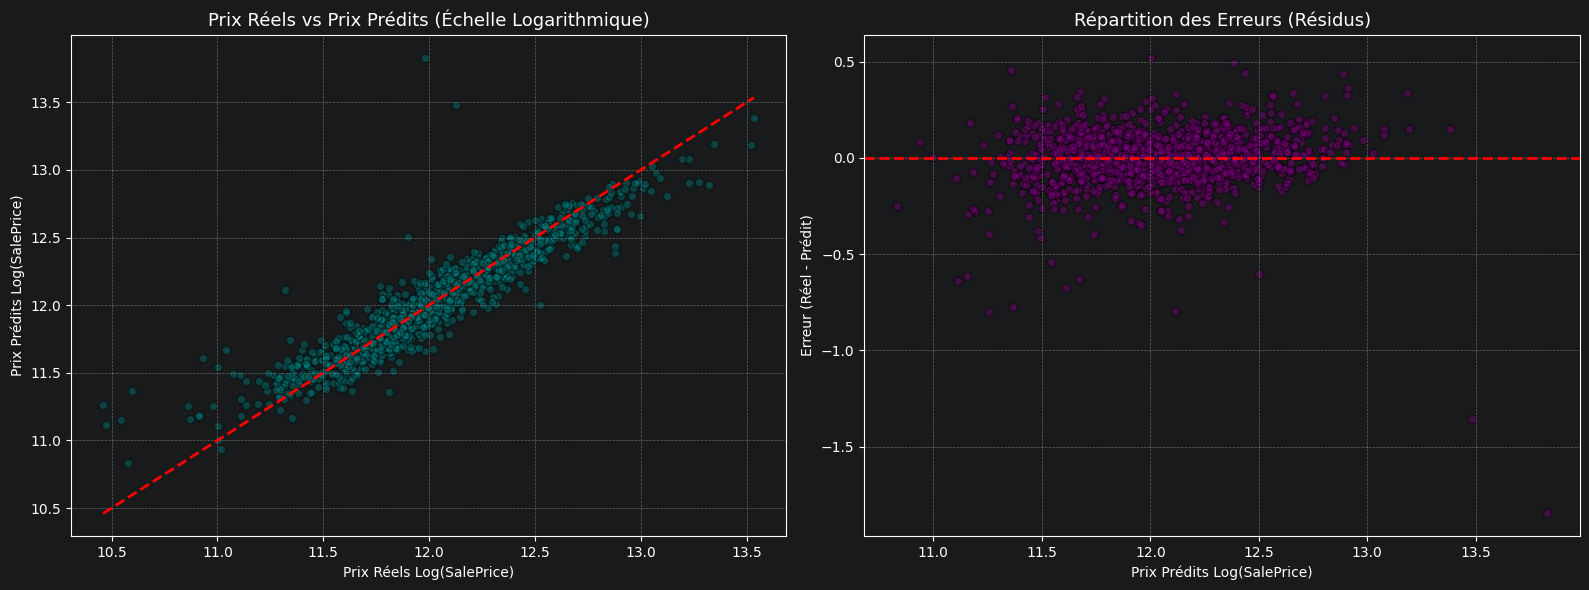

In [34]:
# =====================================================================
# 8. VISUALISATION : PERFORMANCES DU MODÈLE ET RÉSIDUS
# =====================================================================

# On prépare la figure pour avoir 2 graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : Valeurs Réelles vs Valeurs Prédites ---
axes[0].scatter(y_train, y_pred_train, alpha=0.4, color='teal', edgecolor='k')
# On trace la ligne rouge en pointillés parfaite (où Prédiction = Réalité)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)

axes[0].set_title("Prix Réels vs Prix Prédits (Échelle Logarithmique)", fontsize=13)
axes[0].set_xlabel("Prix Réels Log(SalePrice)")
axes[0].set_ylabel("Prix Prédits Log(SalePrice)")
axes[0].grid(True, linestyle='--', alpha=0.5)

# --- Graphique 2 : Analyse des Résidus (Erreurs) ---
# Le résidu, c'est la différence entre ce qu'on a prédit et la réalité
residus = y_train - y_pred_train

axes[1].scatter(y_pred_train, residus, alpha=0.4, color='purple', edgecolor='k')
# On trace la ligne rouge à 0 (l'endroit où l'erreur est nulle)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)

axes[1].set_title("Répartition des Erreurs (Résidus)", fontsize=13)
axes[1].set_xlabel("Prix Prédits Log(SalePrice)")
axes[1].set_ylabel("Erreur (Réel - Prédit)")
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Commentaire pour le Notebook :
# Graphique de gauche : Plus les points sont proches de la ligne rouge, meilleur est le modèle.
# Graphique de droite : On vérifie qu'il n'y a pas de "pattern" ou de forme en entonnoir (homoscédasticité).
# Les erreurs doivent être réparties de manière aléatoire autour de la ligne du zéro.